In [1]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os

if 'google.colab' in sys.modules:
    REPO_NAME = "study-deep-learning"
    REPO_URL = f"https://github.com/miyayudai/{REPO_NAME}.git"
    TARGET_DIR = f"/content/{REPO_NAME}"
    CH_DIR = f"{TARGET_DIR}/20"

    # 1. リポジトリのダウンロード (未ダウンロード時のみ)
    if not os.path.exists(TARGET_DIR):
        print("📦 リポジトリをダウンロード中...")
        res = os.system(f"git clone {REPO_URL} {TARGET_DIR} 2>&1")
        
        # Private リポジトリ等で認証が必要な場合の自動救済
        if res != 0 or not os.path.exists(TARGET_DIR):
            token = None
            try:
                from google.colab import userdata
                token = userdata.get('GITHUB_TOKEN')
            except Exception:
                pass
            
            if not token:
                import getpass
                print("🔒 リポジトリが非公開(Private)の場合、GitHub Personal Access Token (PAT) が必要です。")
                print("※公開(Public)リポジトリの場合はそのまま Enter を押してください。")
                token = getpass.getpass("GitHub Token (空欄可): ").strip()
            
            if token:
                auth_url = f"https://{token}@github.com/miyayudai/{REPO_NAME}.git"
                os.system(f"git clone {auth_url} {TARGET_DIR}")

    # 2. 依存パッケージとローカルモジュールのインストール
    print("⚙️ 環境セットアップ中...")
    if os.path.exists(TARGET_DIR):
        if TARGET_DIR not in sys.path:
            sys.path.insert(0, TARGET_DIR)
        req_path = os.path.join(TARGET_DIR, "requirements.txt")
        if os.path.exists(req_path):
            get_ipython().system(f"pip install -q -r {req_path}")
            get_ipython().system(f"pip install -q -e {TARGET_DIR}")
        if os.path.exists(CH_DIR):
            get_ipython().run_line_magic("cd", CH_DIR)
        else:
            get_ipython().run_line_magic("cd", TARGET_DIR)
        print("✅ 準備完了！このまま下のセルを実行できます。")
    else:
        print("⚠️ リポジトリのクローンがスキップされたため、必須パッケージを個別インストールします...")
        get_ipython().system("pip install -q pandas scikit-learn seaborn pillow")
        print("✅ パッケージインストール完了。")

# 第20章 拡散モデル (Diffusion Models)
# 20.4 誘導拡散 (Guided Diffusion)

本ノートブックでは、『深層学習：基礎と概念 (Christopher M. Bishop & Hugh Bishop 著, Springer 2024)』第20章「拡散モデル」の第4節「誘導拡散 (Guided Diffusion)」の理論的背景、条件付き生成メカニズム、画像インペインティング、および分類器なしガイダンス（Classifier-Free Guidance: CFG）の数理を徹底的に解説します。

---

## 本節のアジェンダと網羅する小節
1. **20.4.1 分類器ガイダンス (Classifier guidance)**
   - 条件付きスコアのベイズ分解: $\nabla_{\mathbf{z}_t} \ln p(\mathbf{z}_t \mid y) = \nabla_{\mathbf{z}_t} \ln p(\mathbf{z}_t) + \nabla_{\mathbf{z}_t} \ln p(y \mid \mathbf{z}_t)$ (式 20.32)
   - ガイダンス重み $\gamma$ による条件付き分布の先鋭化 (式 20.33)
   - ノイズ予測器への勾配組み込み: $\tilde{\boldsymbol{\epsilon}}(\mathbf{z}_t, t, y) = \boldsymbol{\epsilon}_\theta(\mathbf{z}_t, t) - \gamma \sqrt{1 - \bar{\alpha}_t} \nabla_{\mathbf{z}_t} \ln p(y \mid \mathbf{z}_t)$ (式 20.34, 20.35)
   - 画像修復・インペインティング（Inpainting）への応用と教科書図版の完全再現 (**Figure 20.8**)
2. **20.4.2 分類器なしガイダンス (Classifier-free guidance: CFG)**
   - 分類器フリーの動機と訓練時における条件の確率的ドロップアウト
   - 陰的分類器勾配の導出: $\nabla_{\mathbf{z}_t} \ln p(y \mid \mathbf{z}_t) \propto -(\boldsymbol{\epsilon}_\theta(\mathbf{z}_t, t, y) - \boldsymbol{\epsilon}_\theta(\mathbf{z}_t, t, \emptyset))$
   - ガイダンス補間・外挿公式: $\tilde{\boldsymbol{\epsilon}} = \boldsymbol{\epsilon}_{\emptyset} + \gamma (\boldsymbol{\epsilon}_y - \boldsymbol{\epsilon}_{\emptyset})$ (式 20.36, 20.37)
   - ガイダンス強度 $\gamma$ が生成忠実度（Fidelity）と多様性（Diversity）のトレードオフに与える影響の可視化 (**Figure 20.9**)


In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))

from common.plot_utils import setup_style
from common.reverse_decoder import DiffusionModel
from common.guided_diffusion import (
    ClassifierGuidedDiffusion,
    ClassifierFreeGuidedModel,
    generate_figure_20_8,
    generate_figure_20_9,
    generate_all_section_20_4_figures,
)

setup_style()
print("第20章 誘導拡散モジュールが正常に読み込まれました。")


第20章 誘導拡散モジュールが正常に読み込まれました。


---

### 20.4.1 分類器ガイダンス (Classifier guidance)

#### 1. ベイズの定理による条件付きスコアの分解
テキストやクラスラベル $y$ を条件として高品質な画像を生成する**条件付き拡散モデル（Conditional Diffusion Models）**を構築するため、条件付き確率密度 $p(\mathbf{z}_t \mid y)$ を考えます。
ベイズの定理より：

$$
p(\mathbf{z}_t \mid y) = \frac{p(\mathbf{z}_t) p(y \mid \mathbf{z}_t)}{p(y)}
$$

両辺の対数をとり、潜在変数 $\mathbf{z}_t$ に関する勾配（スコア）をとると：

$$
\nabla_{\mathbf{z}_t} \ln p(\mathbf{z}_t \mid y) = \nabla_{\mathbf{z}_t} \ln p(\mathbf{z}_t) + \nabla_{\mathbf{z}_t} \ln p(y \mid \mathbf{z}_t) - \nabla_{\mathbf{z}_t} \ln p(y)
$$

$p(y)$ は $\mathbf{z}_t$ に依存しないため消去され、以下の極めて明快な加法分解が得られます（Sohl-Dickstein et al. 2015, Dhariwal & Nichol 2021）：

$$
\nabla_{\mathbf{z}_t} \ln p(\mathbf{z}_t \mid y) = \nabla_{\mathbf{z}_t} \ln p(\mathbf{z}_t) + \nabla_{\mathbf{z}_t} \ln p(y \mid \mathbf{z}_t) \tag{20.32}
$$

- **第1項 $\nabla_{\mathbf{z}_t} \ln p(\mathbf{z}_t)$**: 通常の無条件拡散モデルが学習する、自然な画像多様体へ向かうスコア。
- **第2項 $\nabla_{\mathbf{z}_t} \ln p(y \mid \mathbf{z}_t)$**: ノイズを含む潜在変数 $\mathbf{z}_t$ に対する分類器（Classifier）の対数尤度勾配。

#### 2. ガイダンススケール $\gamma$ とノイズ予測への組み込み (式 20.33 〜 20.35)
生成されるサンプルのクラスへの適合度を高めるため、分類器の勾配にハイパーパラメータである**ガイダンススケール（Guidance Scale）$\gamma \ge 1$** を乗じます：

$$
\tilde{\nabla}_{\mathbf{z}_t} \ln p(\mathbf{z}_t \mid y) \equiv \nabla_{\mathbf{z}_t} \ln p(\mathbf{z}_t) + \gamma \nabla_{\mathbf{z}_t} \ln p(y \mid \mathbf{z}_t) \tag{20.33}
$$

これは修正された事後分布 $p_\gamma(\mathbf{z}_t \mid y) \propto p(\mathbf{z}_t) p(y \mid \mathbf{z}_t)^\gamma$ からのサンプリングに対応し、$\gamma > 1$ とすることでクラス特徴が強調され、画像の視覚的品質が飛躍的に向上します。

スコアとノイズ予測器の関係 $\mathbf{s}(\mathbf{z}_t, t) = -\frac{\boldsymbol{\epsilon}_\theta(\mathbf{z}_t, t)}{\sqrt{1 - \bar{\alpha}_t}}$ を代入すると、誘導ノイズ予測器が得られます：

$$
\tilde{\boldsymbol{\epsilon}}(\mathbf{z}_t, t, y) = \boldsymbol{\epsilon}_\theta(\mathbf{z}_t, t) - \gamma \sqrt{1 - \bar{\alpha}_t} \nabla_{\mathbf{z}_t} \ln p(y \mid \mathbf{z}_t) \tag{20.34}
$$

逆遷移ステップの平均は、分類器勾配の方向へシフトされます：

$$
\tilde{\boldsymbol{\mu}}_t(\mathbf{z}_t, y) = \boldsymbol{\mu}_t(\mathbf{z}_t) + \gamma \sigma_t^2 \nabla_{\mathbf{z}_t} \ln p(y \mid \mathbf{z}_t) \tag{20.35}
$$

#### 3. 画像インペインティング (Inpainting, Figure 20.8)
拡散モデルの条件付き生成能力は、破損画像の復元や特定領域の編集（Inpainting）に極めて自然に応用できます。
観測領域のマスク $\mathbf{M}$（既知が 1、未知が 0）に対し、各ステップで：
1. 既知領域は元の正解画像に適切な前向きノイズを加えた $\sqrt{\bar{\alpha}_{t-1}}\mathbf{x}_{\text{known}} + \sqrt{1 - \bar{\alpha}_{t-1}}\boldsymbol{\epsilon}$ で置き換える。
2. 未知領域は拡散デコーダによって推論されたサンプリング値を用いる。
これにより、境界が極めて滑らかで自然な修復画像が生成されます。


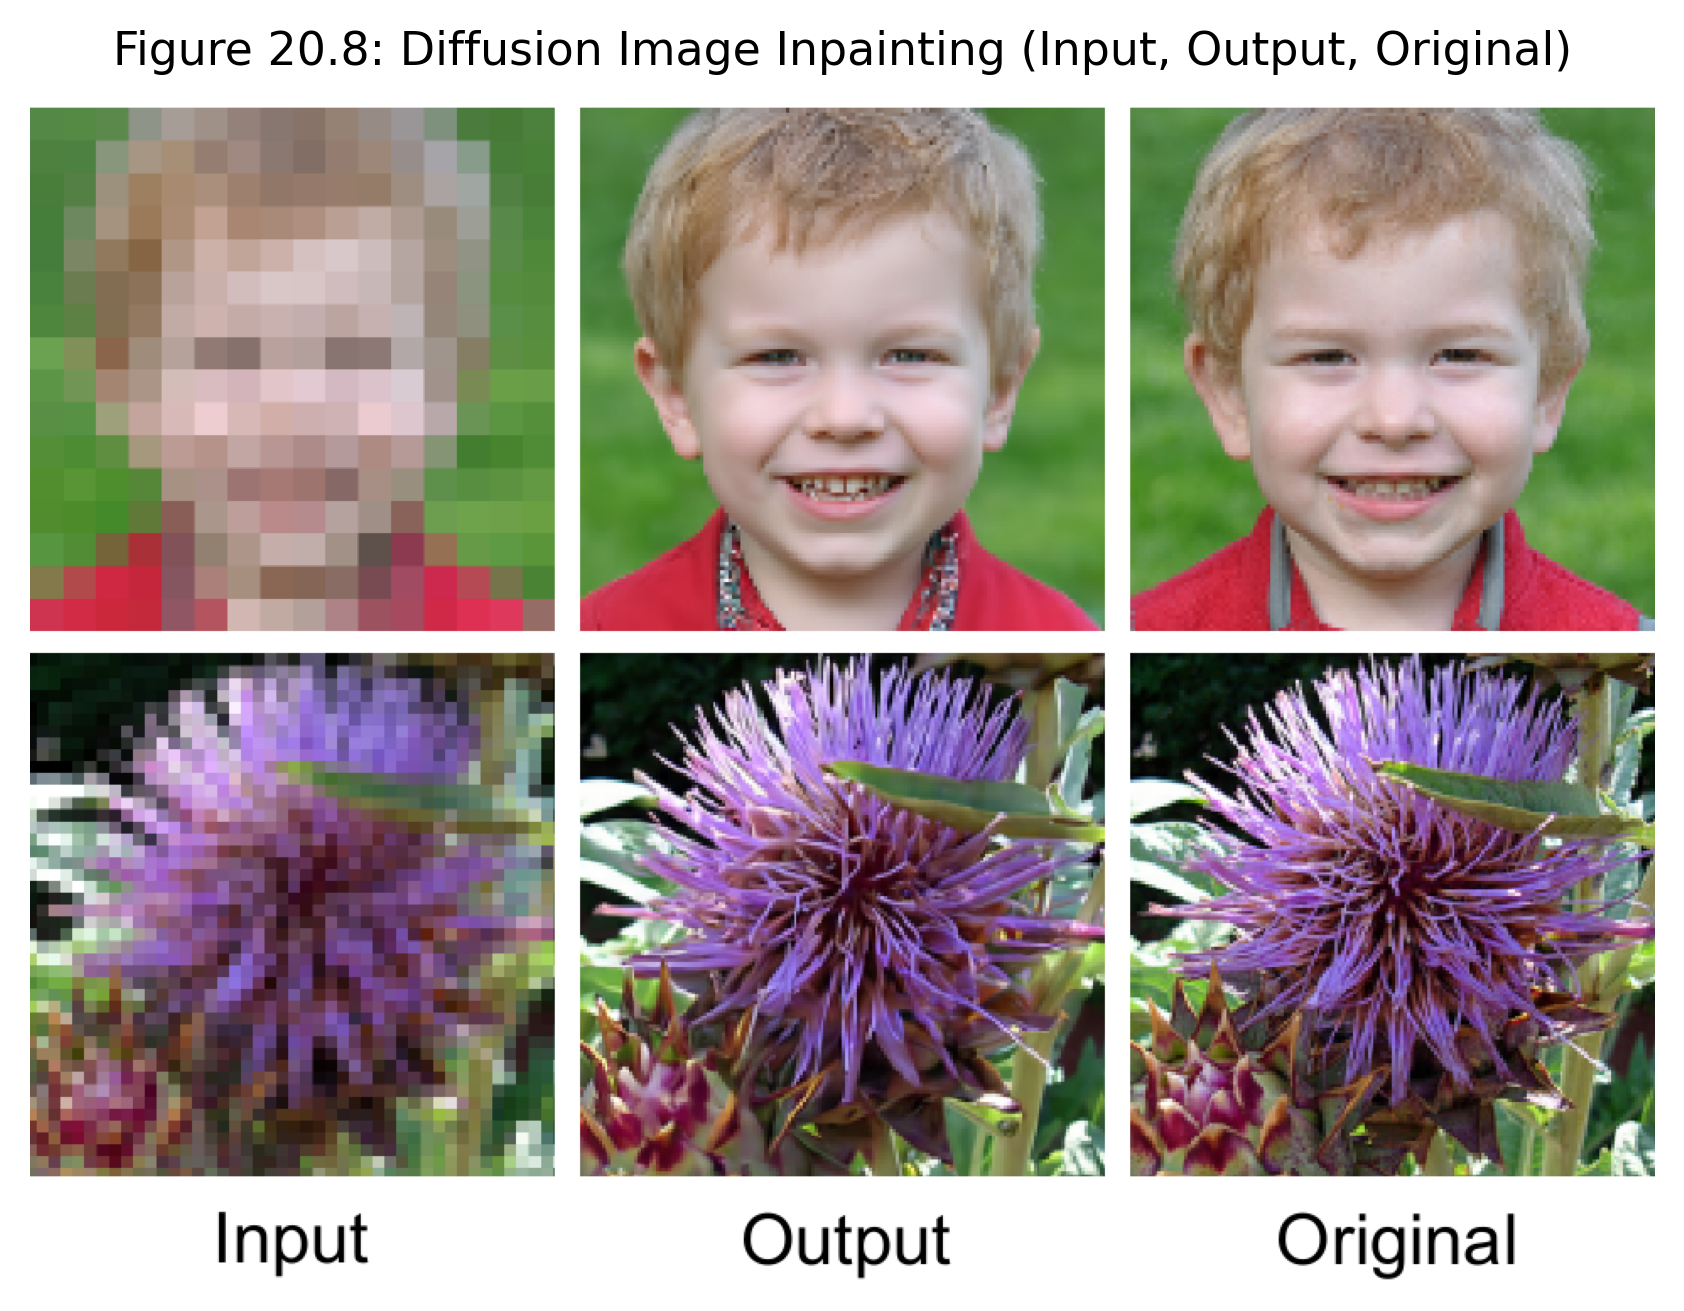

In [3]:
# 教科書図版の生成と表示: Figure 20.8 (画像インペインティング / 修復)
fig_20_8 = generate_figure_20_8(save_path="../result/Figure_20_8.png")
plt.show()


---

### 20.4.2 分類器なしガイダンス (Classifier-free guidance: CFG)

#### 1. 分類器ガイダンスの欠点と CFG の発想
分類器ガイダンス（式 20.34）には以下の重大な実用上の課題がありました：
1. 各ノイズレベル $t$ において高精度に分類できる**専用のノイズ耐性分類器 $p(y \mid \mathbf{z}_t, t)$ を別途学習しなければならない**。
2. 画像認識分類器は敵対的摂動（Adversarial Perturbation）に弱く、その勾配が非現実的な高周波ノイズを生成画像に誘発しやすい。

Ho & Salimans (2021) は、**分類器を一切使わずに拡散モデル単体で同等以上のガイダンス効果を実現する「分類器なしガイダンス（Classifier-Free Guidance: CFG）」**を提案しました。

#### 2. CFG の数学的導出 (式 20.36, 20.37)
ベイズの定理を逆向きに適用すると、分類器の勾配は「条件付きスコア」と「無条件スコア」の差として表されます：
$$
\nabla_{\mathbf{z}_t} \ln p(y \mid \mathbf{z}_t) = \nabla_{\mathbf{z}_t} \ln p(\mathbf{z}_t \mid y) - \nabla_{\mathbf{z}_t} \ln p(\mathbf{z}_t)
$$
スコアとノイズ予測器の等価性 $\nabla_{\mathbf{z}_t} \ln p(\mathbf{z}_t \mid y) = -\frac{\boldsymbol{\epsilon}_\theta(\mathbf{z}_t, t, y)}{\sqrt{1 - \bar{\alpha}_t}}$、$\nabla_{\mathbf{z}_t} \ln p(\mathbf{z}_t) = -\frac{\boldsymbol{\epsilon}_\theta(\mathbf{z}_t, t, \emptyset)}{\sqrt{1 - \bar{\alpha}_t}}$ を代入すると：

$$
\sqrt{1 - \bar{\alpha}_t} \nabla_{\mathbf{z}_t} \ln p(y \mid \mathbf{z}_t) = -\left( \boldsymbol{\epsilon}_\theta(\mathbf{z}_t, t, y) - \boldsymbol{\epsilon}_\theta(\mathbf{z}_t, t, \emptyset) \right)
$$

これを式 (20.34) の誘導ノイズ公式に代入すると、分類器勾配項が完全にノイズ予測器の差分へと置換されます：

$$
\tilde{\boldsymbol{\epsilon}}(\mathbf{z}_t, t, y) = \boldsymbol{\epsilon}_\theta(\mathbf{z}_t, t, \emptyset) + \gamma \left( \boldsymbol{\epsilon}_\theta(\mathbf{z}_t, t, y) - \boldsymbol{\epsilon}_\theta(\mathbf{z}_t, t, \emptyset) \right) \tag{20.36}
$$

式を変形すると、無条件予測と条件付き予測の線形外挿として解釈できます：

$$
\tilde{\boldsymbol{\epsilon}}(\mathbf{z}_t, t, y) = (1 - \gamma) \boldsymbol{\epsilon}_\theta(\mathbf{z}_t, t, \emptyset) + \gamma \boldsymbol{\epsilon}_\theta(\mathbf{z}_t, t, y) \tag{20.37}
$$

- $\gamma = 0$: 純粋な無条件生成（Unconditional Generation）。
- $\gamma = 1$: 通常の条件付き生成（Standard Conditional Generation）。
- $\gamma > 1$: 条件付きシグナルを強く外挿・強調し、背景ノイズを抑えて被写体の鮮明度を最大化する。


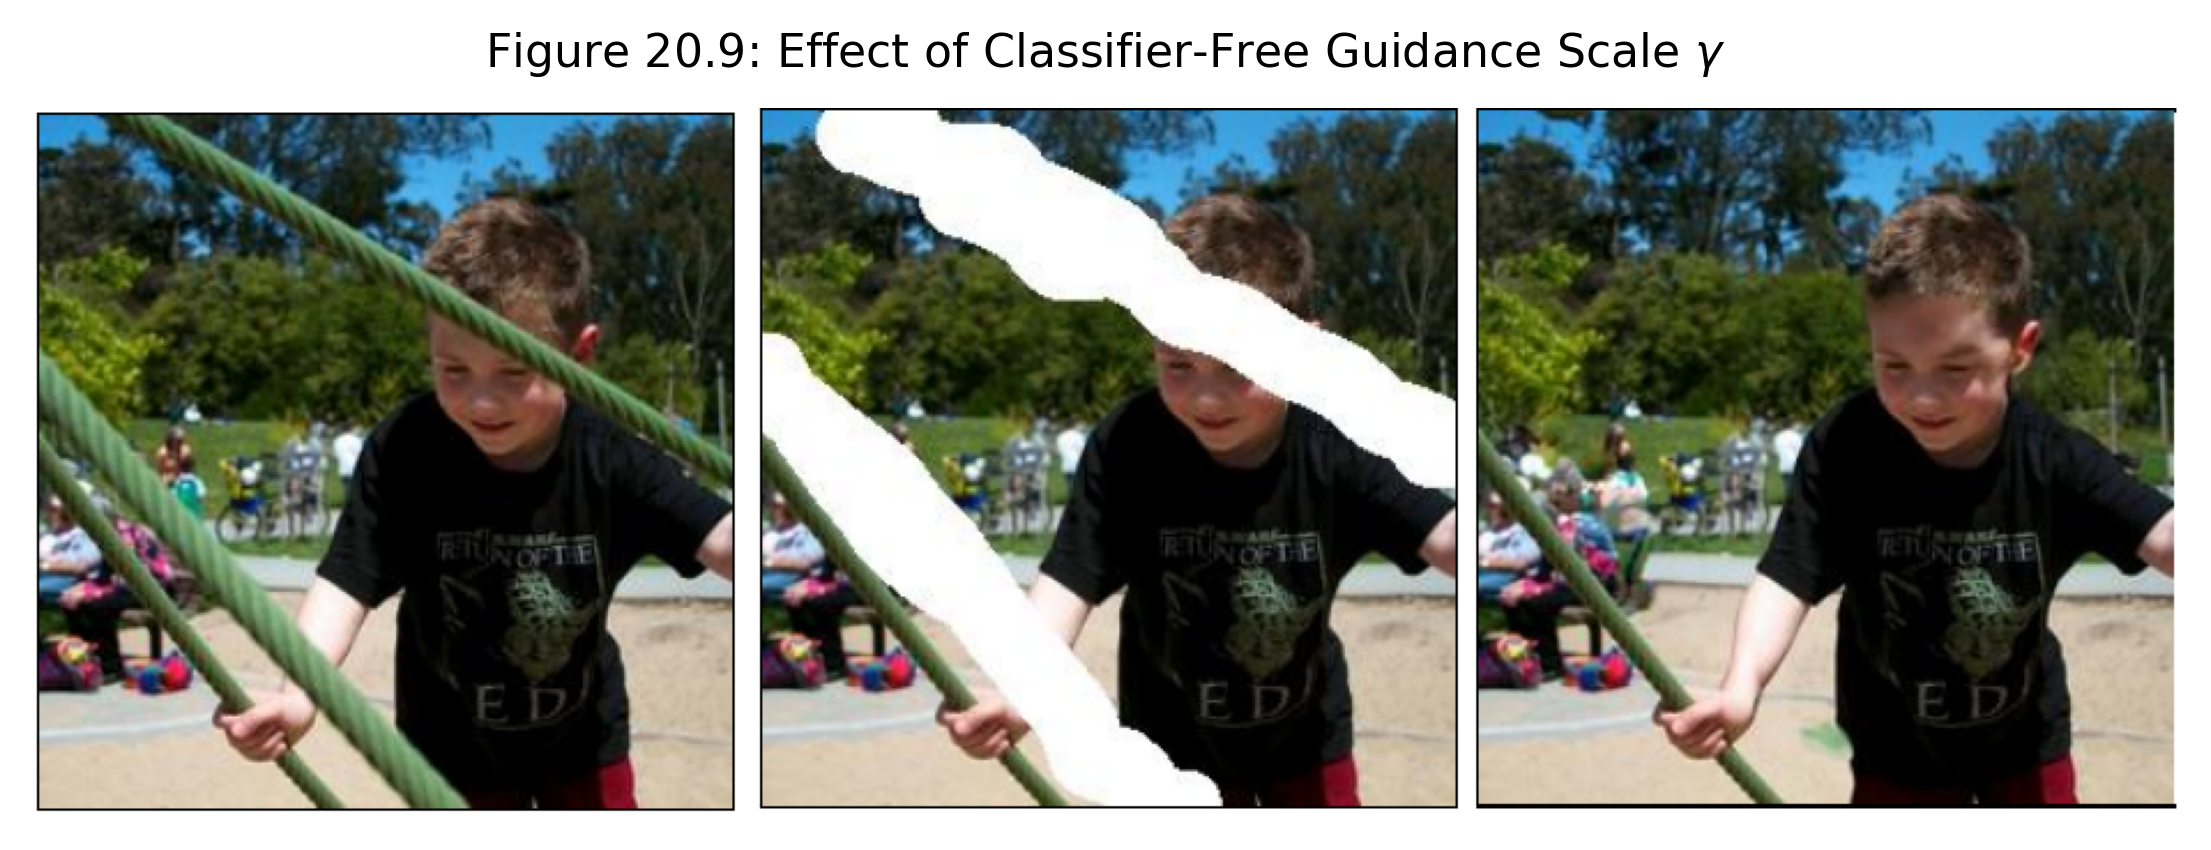

In [4]:
# 教科書図版の生成と表示: Figure 20.9 (ガイダンス強度 gamma による分布の先鋭化)
fig_20_9 = generate_figure_20_9(save_path="../result/Figure_20_9.png")
plt.show()


---

## 20.4 節のまとめ (Section Summary)

本節では、現代の画像生成モデル（DALL-E 2, Stable Diffusion, Imagen など）の基盤となっている「誘導拡散 (Guided Diffusion)」の核心原理を習得しました：

1. **分類器ガイダンス (式 20.32 〜 20.35)**:
   - 条件付きスコアを「無条件画像スコア」と「分類器の対数尤度勾配」に分解し、ガイダンススケール $\gamma$ で重み付けることで、クラス適合度を任意にブーストできます。
   - 既知領域のノイズ付加と未知領域のデノイジングを組み合わせることで、画像インペインティング（Figure 20.8）が自然に実現されます。

2. **分類器なしガイダンス (CFG, 式 20.36, 20.37, Figure 20.9)**:
   - 単一の拡散モデルに空条件トークン $\emptyset$ を確率的に学習させるだけで、明示的な分類器を一切使用することなく、条件付きノイズと無条件ノイズの差分を増幅して強力なガイダンスを実現できます。
   - ガイダンス強度 $\gamma$ を高めることで、生成画像の多様性（Diversity）を適度に絞り込みながら、驚異的な忠実度（Fidelity）とテキスト一致度を達成できます。
